Same as the version3 just XGBoost is used here

In [3]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.8/101.7 MB 3.8 MB/s eta 0:00:27
   - -------------------------------------- 2.6/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 3.9/101.7 MB 4.5 MB/s eta 0:00:22
   -- ------------------------------------- 5.2/101.7 MB 4.9 MB/s eta 0:00:20
   -- ------------------------------------- 7.3/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 9.7/101.7 MB 6.5 MB/s eta 0:00:15
   ---- ----------------------------------- 11.3/101.7 MB 6.6 MB/s eta 0:00:14
   ----- ---------------------------------- 13.4/101.7 MB 7.0 MB/s eta 0:00:13
   ------ --------------------------------- 16.3/101.7 MB 7.6 MB/s eta 0:00:12
   --


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Cell 2: Load Data for XGBoost
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Replace 'adnimerge.csv' with your actual file path
df = pd.read_csv('adnimerge.csv')

target_col = 'DX'

# Base features including demographics, CSF, and the powerful cognitive scores
base_features = ['AGE', 'PTGENDER', 'APOE4', 'ABETA', 'TAU', 'PTAU', 'MMSE', 'CDRSB']

df_model5 = df[['RID', 'VISCODE', target_col] + base_features].copy()
print(f"Initial shape: {df_model5.shape}")

Initial shape: (16421, 11)


C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_20356\3091887224.py:11: DtypeWarning: Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('adnimerge.csv')


In [7]:
# Cell 3: Data Cleaning & Feature Engineering
# 1. Drop rows missing the target diagnosis
df_model5 = df_model5.dropna(subset=[target_col])

# 2. Convert CSF markers to numeric (forces text values to NaN)
for col in ['ABETA', 'TAU', 'PTAU']:
    df_model5[col] = pd.to_numeric(df_model5[col], errors='coerce')

# 3. Drop rows that are missing ANY of the core CSF data
df_model5 = df_model5.dropna(subset=['ABETA', 'TAU', 'PTAU'], how='any')

# 4. ENCODE CATEGORICALS: Convert 'PTGENDER' to numeric
df_model5['PTGENDER'] = df_model5['PTGENDER'].map({'Male': 0, 'Female': 1})

# 5. FEATURE ENGINEERING: Create the protein ratios
df_model5['TAU_ABETA_Ratio'] = df_model5['TAU'] / df_model5['ABETA']
df_model5['PTAU_ABETA_Ratio'] = df_model5['PTAU'] / df_model5['ABETA']

# Define final feature list
final_features5 = [
    'AGE', 'PTGENDER', 'APOE4', 
    'ABETA', 'TAU', 'PTAU', 
    'TAU_ABETA_Ratio', 'PTAU_ABETA_Ratio',
    'MMSE', 'CDRSB'
]

# Drop any rows missing the cognitive scores or demographics
df_model5 = df_model5.dropna(subset=final_features5)

print("Class distribution for target (DX) AFTER cleaning:")
print(df_model5[target_col].value_counts())

# Define X5 and y5
X5 = df_model5[final_features5]
y5 = df_model5[target_col]

Class distribution for target (DX) AFTER cleaning:
DX
MCI         911
CN          576
Dementia    509
Name: count, dtype: int64


In [8]:
# Cell 4: Splitting and Scaling
# Split the data
X_train5, X_test5, y_train5, y_test5 = train_test_split(X5, y5, test_size=0.20, random_state=42, stratify=y5)

# Scale the features
scaler5 = StandardScaler()
X_train_scaled5 = scaler5.fit_transform(X_train5)
X_test_scaled5 = scaler5.transform(X_test5)

print(f"Training features shape: {X_train_scaled5.shape}")

Training features shape: (1596, 10)


In [9]:
# Cell 5: Label Encoding and Model Training
# 1. Encode Target Labels
label_encoder5 = LabelEncoder()
y_train_encoded5 = label_encoder5.fit_transform(y_train5)

# We map test values using transform (no fit)
y_test_encoded5 = label_encoder5.transform(y_test5)

# 2. Initialize XGBoost
xgb_classifier5 = XGBClassifier(
    n_estimators=200,          # Number of sequential trees
    max_depth=4,               # Shallower trees to prevent overfitting the MCI boundary
    learning_rate=0.05,        # Slower learning rate for better generalization
    subsample=0.8,             # Use 80% of data per tree for robustness
    eval_metric='mlogloss',
    random_state=42
)

# 3. Train the model
xgb_classifier5.fit(X_train_scaled5, y_train_encoded5)

print("XGBoost (Model 5) training complete.")

XGBoost (Model 5) training complete.


Accuracy Score: 0.86

Classification Report:
               precision    recall  f1-score   support

          CN       0.94      0.89      0.91       115
    Dementia       0.82      0.81      0.82       102
         MCI       0.83      0.87      0.85       183

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



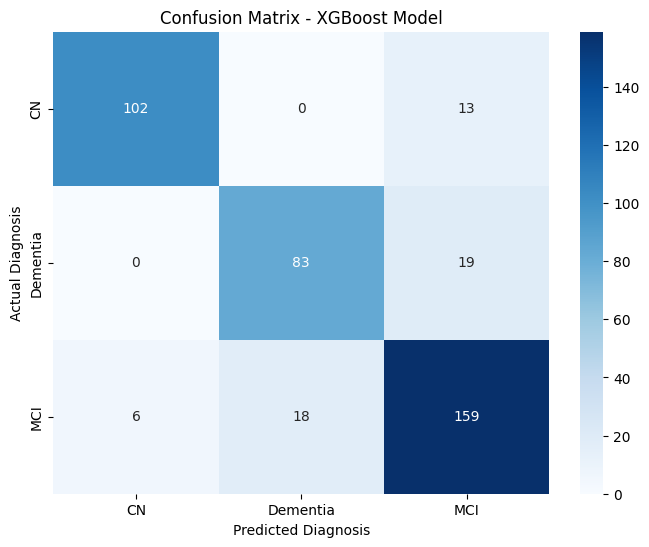

C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_20356\2611735482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df5, palette='viridis')


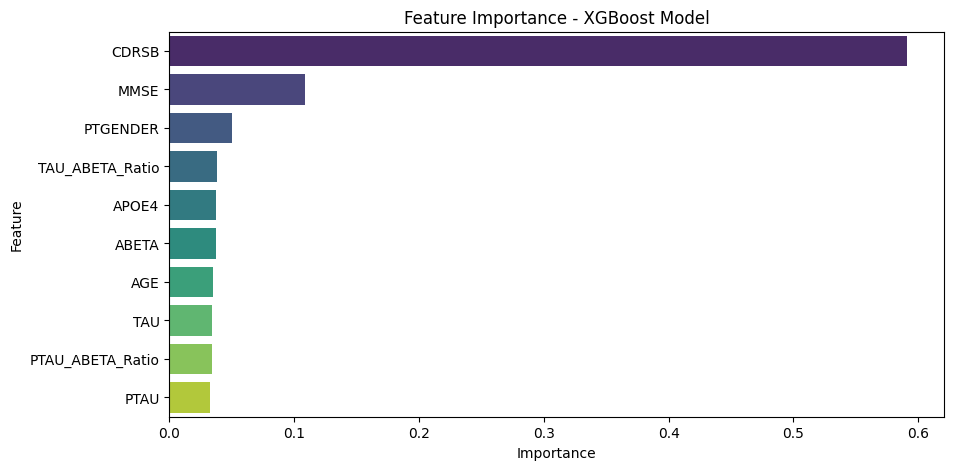

In [10]:
# Cell 6: Predictions and Evaluation
# 1. Make numeric predictions
y_pred_encoded5 = xgb_classifier5.predict(X_test_scaled5)

# 2. Convert predictions back to text (CN, MCI, Dementia) for readability
y_pred5 = label_encoder5.inverse_transform(y_pred_encoded5)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test5, y_pred5))
print("\nClassification Report:\n", classification_report(y_test5, y_pred5))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm5 = confusion_matrix(y_test5, y_pred5, labels=label_encoder5.classes_)
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder5.classes_, 
            yticklabels=label_encoder5.classes_)
plt.title('Confusion Matrix - XGBoost Model')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance for XGBoost
feature_importances5 = xgb_classifier5.feature_importances_
importance_df5 = pd.DataFrame({
    'Feature': final_features5,
    'Importance': feature_importances5
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df5, palette='viridis')
plt.title('Feature Importance - XGBoost Model')
plt.show()

In [ ]:
# Doing hyperparameter tuning using the GridSearchCV
# Right now, we are using manual guesses for XGBoost settings (max_depth=4, learning_rate=0.05). Instead of guessing, 
# we can force the computer to test hundreds of different combinations of settings to find the mathematically perfect configuration for your specific dataset.

Starting Grid Search... Please wait.
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Grid Search Complete!
Best Parameters Found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

--- Optimized Model Evaluation ---
Tuned Accuracy Score: 0.8475

Tuned Classification Report:
               precision    recall  f1-score   support

          CN       0.92      0.89      0.90       115
    Dementia       0.81      0.80      0.81       102
         MCI       0.82      0.85      0.84       183

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



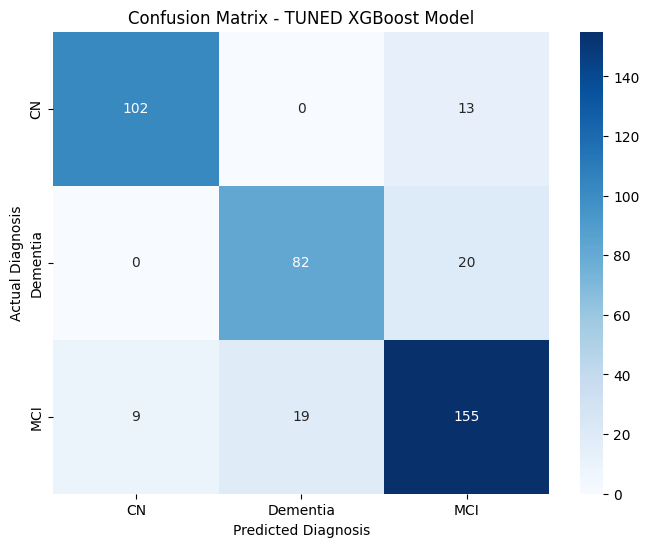

In [11]:
# Cell 7: Hyperparameter Optimization for XGBoost
from sklearn.model_selection import GridSearchCV

# 1. Define the grid of parameters we want the computer to test
param_grid = {
    'max_depth': [3, 4, 5, 6],                  # How deep the trees can go
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    # How fast the model learns
    'n_estimators': [100, 200, 300],            # Number of trees
    'subsample': [0.8, 1.0],                    # Percentage of data used per tree
    'colsample_bytree': [0.8, 1.0]              # Percentage of features used per tree
}

# 2. Initialize a fresh, empty XGBoost classifier
xgb_base = XGBClassifier(eval_metric='mlogloss', random_state=42)

# 3. Set up the Grid Search
# cv=5 means it will do 5-fold cross-validation to ensure the results are robust
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    verbose=1, 
    n_jobs=-1  # Uses all your computer's CPU cores to make it run faster
)

# 4. Run the Search (This will take a minute or two!)
print("Starting Grid Search... Please wait.")
grid_search.fit(X_train_scaled5, y_train_encoded5)

# 5. Get the best model
best_xgb_model = grid_search.best_estimator_

print(f"\nGrid Search Complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")

# 6. Evaluate the mathematically optimized model
y_pred_encoded_tuned = best_xgb_model.predict(X_test_scaled5)
y_pred_tuned = label_encoder5.inverse_transform(y_pred_encoded_tuned)

print("\n--- Optimized Model Evaluation ---")
print("Tuned Accuracy Score:", accuracy_score(y_test5, y_pred_tuned))
print("\nTuned Classification Report:\n", classification_report(y_test5, y_pred_tuned))

# Plot the new Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
cm_tuned = confusion_matrix(y_test5, y_pred_tuned, labels=label_encoder5.classes_)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder5.classes_, 
            yticklabels=label_encoder5.classes_)
plt.title('Confusion Matrix - TUNED XGBoost Model')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()